In [147]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import chi2_contingency
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import  cross_val_predict
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import FeatureUnion
from sklearn.impute import MissingIndicator
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import f1_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import os
import glob
import joblib
from sklearn.metrics import confusion_matrix
from optbinning import BinningProcess, Scorecard
from skorch import NeuralNetClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import precision_recall_curve, average_precision_score


warnings.filterwarnings('ignore')

In [148]:
#Models of interest
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import joblib
from torch.optim import Adam
from skorch import NeuralNetClassifier

import torch 
import torch.nn as nn

In [149]:
X_train_fe = pd.read_csv("X_train_fe.csv")
X_val_fe = pd.read_csv("X_val_fe.csv")
X_test_fe = pd.read_csv("X_test_fe.csv")

In [150]:
y_train = pd.read_csv("y_train.csv").squeeze("columns")
y_val = pd.read_csv("y_val.csv").squeeze("columns")
y_test = pd.read_csv("y_test.csv").squeeze("columns")

In [151]:
def get_class0_probability(model, X):
    #Paramaters include the model of choice to use and the datapoint to predict for
    """
    Gets predicted probability for class 0.
    Works for normal sklearn models and GridSearchCV/RandomizedSearchCV.
    """
    #Checks if the model has a best estimator attribute
    if hasattr(model, "best_estimator_"):
        #gets the best tuned model from the search object
        model = model.best_estimator_
    
    #Gets the predicted probability for each class
    #Important to not assume that first column represents class 0
    proba = model.predict_proba(X)
    
    #Extracts which column or index belongs to class 0
    class_index = list(model.classes_).index(0)
    
    #Returns only the probabilities for class 0
    return proba[:, class_index]

In [152]:
def predict_with_threshold(y_prob_class0, threshold):
    """
    If probability of class 0 >= threshold, predict class 0.
    Otherwise predict class 1.
    """
    #Where function used to denote a number 0 if true and 1 otherwise
    return np.where(y_prob_class0 >= threshold, 0, 1)

In [153]:
def cramers_V(x,y):
    '''
    Here we calculate the Cramer's V to asses the strength of association between 2 nominal variables
    '''
    table =pd.crosstab(x,y)
    #Extract only the chi-square statistics
    chi2=chi2_contingency(table)[0]
    n = table.sum().sum()
    r,k = table.shape
    return np.sqrt(chi2 / (n*(min(r,k) -1)))

In [154]:
class Feature_engineering_step(BaseEstimator,TransformerMixin):
    def __init__(self,date_cols):
        self.date_cols = date_cols


    def fit(self,X,y=None):
        X= X.copy()

        # Make sure date columns are actually datetime
        for col in self.date_cols:
            X[col] = pd.to_datetime(X[col], errors="coerce")

        self.current_t_ = X[self.date_cols].max().max()
        return self
    
    def transform(self,X):
        X = X.copy()

        for col in self.date_cols:
            X[col] = pd.to_datetime(X[col], errors="coerce")

        X["customer_history"] = (X['issue_d'] - X["earliest_cr_line"]).dt.days
        X["months_since_earliest_credit_line"] = (
            (self.current_t_.year - X["earliest_cr_line"].dt.year) * 12
            + (self.current_t_.month - X["earliest_cr_line"].dt.month)
        )

        X["loan_age_months"] = ((self.current_t_.year - X["issue_d"].dt.year) * 12
                                + (self.current_t_.month - X["issue_d"].dt.month))
        
        X["current_balance_ratio"] = (
            X["out_prncp"] / X["loan_amnt"].replace(0, np.nan)
        )

        X["payment_progress_ratio"] = (
            X["total_rec_prncp"] / X["loan_amnt"].replace(0, np.nan)
        )

        X = X.drop(columns=self.date_cols)

        X["term_months"] = X["term"].str.extract("(\d+)").astype(float)

        emp_length_map = {
    "< 1 year": 0,
    "1 year": 1,
    "2 years": 2,
    "3 years": 3,
    "4 years": 4,
    "5 years": 5,
    "6 years": 6,
    "7 years": 7,
    "8 years": 8,
    "9 years": 9,
    "10+ years": 10
    }

        X["emp_length_num"] = X["emp_length"].map(emp_length_map)

        X["int_rate"] = X["int_rate"].astype(str).str.replace("%", "", regex=False).astype(float)
        X["revol_util"] = X["revol_util"].astype(str).str.replace("%", "", regex=False).astype(float)

        # Drop original text versions
        X = X.drop(columns=["term", "emp_length"])


        return X


In [155]:
#self.Q1_ saves the learned threshold from training so it can be consistently applied to new data.
class OutlierFlaggerv2(BaseEstimator, TransformerMixin):
    #Sklearn pipeline uses both x and y so thus we add y=None
    def fit(self,X, y=None):
        #To keep track of the columns
        X = pd.DataFrame(X)
        X.columns = X.columns.astype(str)
        self.feature_names_in_ = list(X.columns)
        self.Q1 = X.quantile(0.25)
        self.Q3 = X.quantile(0.75)
        self.IQR = self.Q3 - self.Q1
        #Return the capsulated info obtained
        return self

    def transform(self,X):
        X = pd.DataFrame(X, columns=self.feature_names_in_)
        X.columns = X.columns.astype(str)
        lower = self.Q1 -  1.5*self.IQR
        upper = self.Q3 +  1.5*self.IQR
        flags = ((X < lower) |(X>upper)).astype(int)
        #We keep the original feature and add a new column to capture outlier information, not replace it.

        flags.columns = [str(col) + "_outlier" for col in X.columns]
        
        return flags
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            #Store the input features in a variable, then to a list
            input_features = self.feature_names_in_
        input_features = [str(col) for col in input_features]
        outlier_names = [col + "_outlier" for col in input_features]
        return np.array(outlier_names, dtype=object)

In [156]:
class Missing_val_dropper(BaseEstimator,TransformerMixin):
    def __init__(self, threshold = 50.0):
        self.threshold = threshold

    def fit(self,X,y=None):
        #learns the columns to drop
        X = pd.DataFrame(X).copy()

        #Missing percent vector that holds the missing percentage indexed by the col names
        missing_percent = X.isna().mean() * 100

        #Columns with  >= threshold missigness
        self.columns_to_drop = missing_percent[missing_percent >= self.threshold].index.tolist()

        self.feature_names = X.columns.tolist()
        return self
    
    def transform(self,X):
        #actually drops the columns
        X = pd.DataFrame(X).copy()
        return X.drop(columns=self.columns_to_drop,errors="ignore")
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names

        return np.array([
            col for col in input_features
            if col not in self.columns_to_drop
        ])

In [157]:
#Version to fit into the pipeline
class CategoricalFeatureSelector(BaseEstimator,TransformerMixin):
    def __init__(self, threshold=0.80):
        self.threshold = threshold

    def fit(self,X,y=None):
        X = pd.DataFrame(X)
        self.feature_names = list(X.columns)

        to_drop = set()

        for i in range(len(self.feature_names)):
            for j in range(i + 1, len(self.feature_names)):
                col1 = self.feature_names[i]
                col2 = self.feature_names[j]
                
                v = cramers_V(X[col1], X[col2])
                
                if v > self.threshold:
                    # compare usefulness with target using mutual info
                    x1_encoded = pd.factorize(X[col1])[0].reshape(-1, 1)
                    x2_encoded = pd.factorize(X[col2])[0].reshape(-1, 1)

                    mi1 = mutual_info_classif(x1_encoded, y, discrete_features=True, random_state=45)
                    mi2 = mutual_info_classif(x2_encoded, y, discrete_features=True, random_state=45)
                    
                    if mi1[0] >= mi2[0]:
                        to_drop.add(col2)
                    else:
                        to_drop.add(col1)
        self.columns_to_drop= list(to_drop)
        return self
    
    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X = X.drop(columns=self.columns_to_drop, errors="ignore")
        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names

        input_features = np.array(input_features)

        return np.array([
            col for col in input_features
            if col not in self.columns_to_drop
        ])


In [158]:
#Version to fit into the pipeline
class CorrelationFeatureSelector(BaseEstimator,TransformerMixin):
    def __init__(self, threshold=0.80):
        self.threshold = threshold

    def fit(self,X,y=None):
        X = pd.DataFrame(X)

        corr_matrix = X.corr(numeric_only=True).abs()

        mask = np.triu(np.ones_like(corr_matrix), k=1).astype(bool)
        upper = corr_matrix.where(mask)

        #Use the set to not collect duplicates
        columns_to_drop = set()

        for col in upper.columns:
            for row in upper.index:
                if upper.loc[row,col] > self.threshold and pd.notna(upper.loc[row, col]):
                    #mutual info needs to be 2d inputted
                    mi_row = mutual_info_classif(X[[row]],y,random_state=45)
                    mi_col = mutual_info_classif(X[[col]],y,random_state=45)
                    #reminder larger values means stronger association
                    if mi_row[0] >= mi_col[0]:
                        columns_to_drop.add(col)
                    else:
                        columns_to_drop.add(row)
        self.columns_to_drop = list(columns_to_drop)
        self.feature_names = list(X.columns)

        return self
    
    def transform(self,X):
        X = pd.DataFrame(X,columns=self.feature_names)
        return X.drop(columns=self.columns_to_drop,errors="ignore")
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names

        return np.array(
            [col for col in input_features if col not in self.columns_to_drop],
            dtype=object
        )


In [159]:

numerical_columns_train_fe = X_train_fe.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_columns_train_fe = X_train_fe.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

In [160]:

#I barely added the missing indicator when it should have been in the beggining 5/14. Will use it for the final model evaluation
categorical_pipeline = Pipeline([
    ("drop_missing_cols", Missing_val_dropper(threshold=50.0)),
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing", add_indicator=True)),
    ("cat_selector", CategoricalFeatureSelector(threshold=0.80)),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

numerical_pipeline = Pipeline([
    ("drop_missing_cols", Missing_val_dropper(threshold=50.0)),
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("outlier", OutlierFlaggerv2()),
    ("scaler", RobustScaler())
])

In [161]:
preprocessing = ColumnTransformer([
    ("cat", categorical_pipeline, categorical_columns_train_fe),
    ("num", numerical_pipeline, numerical_columns_train_fe)
], remainder="passthrough")

In [162]:
def model_summary(fitted_model, X_val,y_val,model_name):
    #Predicted probabilities for DV of 0
    y_probs = fitted_model.predict_proba(X_val)[:,0]
    y_pred = fitted_model.predict(X_val)

    class_report = classification_report(y_val,y_pred)
    # ROC values
    fpr, tpr, thresholds = roc_curve(y_val, y_probs, pos_label=0)

    # AUC
    auc = roc_auc_score(1-y_val, y_probs)

    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    #Baseline
    plt.plot([0, 1], [0, 1], linestyle='--') 
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve of DV=0")
    plt.legend()
    plt.show()


    print(class_report)
    print(f"current model auc:{auc:3f}")
    print(f"current model name:{model_name}")

In [163]:
def Youden_threshold(fitted_model, X_val, y_val):
    
    # Probability of original class 0
    y_probs = fitted_model.predict_proba(X_val)[:, 0]

    # Treat original class 0 as the positive class
    fpr, tpr, thresholds = roc_curve(y_val, y_probs, pos_label=0)

    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    j_threshold = thresholds[best_idx]

    print(f"Youden threshold for class 0: {j_threshold}")
    
    # Predict class 0 if probability of class 0 is above threshold
    y_pred_changed = np.where(y_probs >= j_threshold, 0, 1)
   
    print("Classification report with threshold")
    print(classification_report(y_val, y_pred_changed))

    return j_threshold

In [164]:
def f1_threshold(fitted_model, X_val, y_val):

    # Probability of class 0
    y_probs_0 = fitted_model.predict_proba(X_val)[:, 0]

    thresholds = np.linspace(0, 1, 100)
    f1_scores = []

    for t in thresholds:
        # Predict class 0 if probability of class 0 >= threshold
        y_pred = np.where(y_probs_0 >= t, 0, 1)

        # F1 score for class 0
        score = f1_score(y_val, y_pred, pos_label=0)
        f1_scores.append(score)

    best_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[best_idx]

    print(f"F1 optimal threshold for class 0: {optimal_threshold}")

    y_pred_optimal = np.where(y_probs_0 >= optimal_threshold, 0, 1)

    print("Classification report with threshold")
    print(classification_report(y_val, y_pred_optimal))

    return optimal_threshold

In [165]:
#Finds all the files in the current cworking directory that end with '.pkl'
model_files = glob.glob("*.pkl")

print("Found models:")
for file in model_files:
    print(file)

#Dictiorary initializer
models = {}

for file in model_files:
    try:
        model = joblib.load(file)
        models[file] = model
        print("\n" + "="*80)
        print(f"MODEL FILE: {file}")
        print("="*80)
        print(model)
        
        # If it is GridSearchCV or RandomizedSearchCV attributes
        if hasattr(model, "best_params_"):#Checks if the object hast attribute called best_params
            print("\nBest Parameters:")
            print(model.best_params_)
            
        if hasattr(model, "best_score_"):
            print("\nBest CV Score:")
            print(model.best_score_)
            
        if hasattr(model, "best_estimator_"):
            print("\nBest Estimator:")
            print(model.best_estimator_)
            
    except Exception as e:
        #Catches an exception and stroes the error in  the variable e
        print(f"Could not load {file}: {e}")

Found models:
bagging_search_model.pkl
best_largenn.pkl
best_XGB_sampler_model.pkl
best_XGB_sampler_model_smoted.pkl
large_nn_original_pipeline_final_model.pkl
lr_l1_sampler_model.pkl
lr_l1_weights_model.pkl
lr_l2_sampler_model.pkl
lr_l2_weights_model.pkl
rf_model.pkl
XGB_mixed_model.pkl
XGB_no_sampler_model.pkl

MODEL FILE: bagging_search_model.pkl
RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               Pipeline(steps=[('drop_missing_cols',
                                                                                                Missing_val_dropper()),
                                                                                               ('imputer',
                                            

In [166]:


def patch_simple_imputer(estimator):
    #Estimator could be pipeline, simpleimputer,columntransformer, gridsearch/randomized search
    """
    Adds missing internal _fill_dtype attribute to SimpleImputer objects.(only)
    This is a quick compatibility patch for old/new sklearn pickle issues.
    """
    
    if isinstance(estimator, SimpleImputer):
        #Checks if the estimator is a simpleIMputer
        if not hasattr(estimator, "_fill_dtype"):
            #Checks it does not have fill_dtype attribute
            #prevents overwriting the attribute if it already exists
            
            # If categorical/string imputer
            if estimator.strategy == "constant" and isinstance(estimator.fill_value, str):
                #If the esttimator is an imputer that imputes via constant that is a string it
                #Denotes and treats the column as a object datatype
                estimator._fill_dtype = object
            
            # If statistics are string/object
            elif hasattr(estimator, "statistics_") and estimator.statistics_.dtype.kind in ["O", "U", "S"]:
                #If the imputer has already learned string/object statistics it set the column 
                #as an object datatype
                estimator._fill_dtype = object
            
            # Otherwise numeric
            else:
                estimator._fill_dtype = np.float64

    # Recursively patch nested estimators
    if hasattr(estimator, "steps"):
        #CHecks whether the current object has attributes steps, usually in pipeline objects
        #The imputer may be in a pipeline
        for _, step in estimator.steps:
            #Loops throguh the pipeline steps which have the following form
            #("step_name", step_object)
            patch_simple_imputer(step)

    if hasattr(estimator, "transformers_"):
        #Checks if the object fitted Transformer
        for _, transformer, _ in estimator.transformers_:
            #Loops throguth each transformer in the columntransformer
            #Each having 3 parts ("name", transformer_object, columns)
            if transformer != "drop" and transformer != "passthrough":
                #Looking for the imputer class and not the attributes directly
                #Fixes the fill_type attribute only
                patch_simple_imputer(transformer)

    if hasattr(estimator, "best_estimator_"):
        #Made for the searches type obects
        #This applies the patch to the best model
        patch_simple_imputer(estimator.best_estimator_)

        #Returns the fixed estimator

    return estimator

In [167]:


def patch_all_simple_imputers(estimator):
    """
    Recursively searches through any sklearn/imblearn pipeline,
    GridSearchCV, ColumnTransformer, etc., and patches all SimpleImputer objects.
    """
    #Creates a set because we remember the models that are checked
    #Important because pipelines can reference the same object more than once
    seen = set()

    def _patch(obj):
        #Returns if the object is empty or missing
        if obj is None:
            return
        
        #Get the object unique memory ID
        obj_id = id(obj)
        #If the object was seen return, otherwise add it to seen
        if obj_id in seen:
            return
        seen.add(obj_id)

        # Patch SimpleImputer
        if isinstance(obj, SimpleImputer):
            if not hasattr(obj, "_fill_dtype"):
                if obj.strategy == "constant":
                    if isinstance(obj.fill_value, str):
                        obj._fill_dtype = object
                    #elif checks if the first condition was wrong
                    elif obj.fill_value is None:
                        obj._fill_dtype = object
                    else:
                        #This is basically if the column is a numeric, then change to numeric type
                        obj._fill_dtype = np.asarray(obj.fill_value).dtype
                else:
                    if hasattr(obj, "statistics_"):
                        #Handles non constant imputers such as strategy 'mean,median, most_frequent'
                        obj._fill_dtype = obj.statistics_.dtype
                        #uses the dtype of the learned statistic, if not then default to float 64
                    else:
                        obj._fill_dtype = np.float64

        # Patch best_estimator_ if GridSearchCV/RandomizedSearchCV
        if hasattr(obj, "best_estimator_"):
            _patch(obj.best_estimator_)

        # Patch estimator if search object has base estimator
        if hasattr(obj, "estimator"):
            #Instance like bagginclassifier that has a wrapped baseline model
            _patch(obj.estimator)

        # Patch pipeline steps
        if hasattr(obj, "steps"):
            #Patches the steps in a pipeline
            for _, step in obj.steps:
                _patch(step)

        # Patch ColumnTransformer fitted transformers
        if hasattr(obj, "transformers_"):
            for _, transformer, _ in obj.transformers_:
                if transformer not in ["drop", "passthrough"]:

                    _patch(transformer)

        # Patch ColumnTransformer original transformers
        #Examples : ("num", numeric_pipeline, numeric_columns)
        #("cat", categorical_pipeline, categorical_columns)
        #numeric_pipeline, ctageorical piepeline, simpleIputer, oneHotencoder
        #So just the objects
        if hasattr(obj, "transformers"):
            for _, transformer, _ in obj.transformers:
                if transformer not in ["drop", "passthrough"]:
                    _patch(transformer)

        # Last resort: search all nested sklearn params
        #Check the parameters
        if hasattr(obj, "get_params"):
            try:
                #Deep = True looks at the nested objects, like model in pipeline, preprocess, preprocess_num etc 
                for param in obj.get_params(deep=True).values():
                    _patch(param)
            except Exception:
                pass

    _patch(estimator)
    return estimator

In [168]:
for model_name in models:
    models[model_name] = patch_all_simple_imputers(models[model_name])

print("All models patched.")

All models patched.


In [169]:
for model_name in models:
    models[model_name] = patch_simple_imputer(models[model_name])

print("All models patched.")

All models patched.


In [170]:

#Checks every model specs and everything
model_summary_df = []

for model_name, model in models.items():
    print("\nChecking:", model_name)

    try:
        f1_t = f1_threshold(model, X_val_fe, y_val)
        youden_t = Youden_threshold(model, X_val_fe, y_val)

        y_val_proba_class1 = model.predict_proba(X_val_fe)[:, 1]
        auc_roc = roc_auc_score(y_val, y_val_proba_class1)

        model_summary_df.append({
            "model_name": model_name,
            "auc_roc": auc_roc,
            "f1_threshold": f1_t,
            "youden_threshold": youden_t
        })

        print("Success")

    except Exception as e:
        print("Error:", e)

model_summary_df = pd.DataFrame(model_summary_df)

print(model_summary_df)


Checking: bagging_search_model.pkl
F1 optimal threshold for class 0: 0.5555555555555556
Classification report with threshold
              precision    recall  f1-score   support

           0       0.30      0.58      0.39      4822
           1       0.90      0.74      0.81     25178

    accuracy                           0.71     30000
   macro avg       0.60      0.66      0.60     30000
weighted avg       0.80      0.71      0.74     30000

Youden threshold for class 0: 0.5028879772402
Classification report with threshold
              precision    recall  f1-score   support

           0       0.26      0.75      0.38      4822
           1       0.93      0.59      0.72     25178

    accuracy                           0.61     30000
   macro avg       0.59      0.67      0.55     30000
weighted avg       0.82      0.61      0.66     30000

Success

Checking: best_XGB_sampler_model.pkl
F1 optimal threshold for class 0: 0.4646464646464647
Classification report with threshold
 

In [171]:
final_results = []

for i, row in model_summary_df.iterrows():
    #Loops through each row returning the index of teh row and the row contents
    # IN a pandas series

    model_name = row["model_name"]
    model = models[model_name]   # FIXED LINE

    f1_t = row["f1_threshold"]
    youden_t = row["youden_threshold"]

    y_prob_class0 = get_class0_probability(model, X_val_fe)

    y_pred_f1 = predict_with_threshold(y_prob_class0, f1_t)
    y_pred_youden = predict_with_threshold(y_prob_class0, youden_t)

    print("\n" + "="*80)
    print(f"MODEL: {model_name}")
    print("="*80)

    print(f"\nF1 Threshold: {f1_t}")
    print(classification_report(y_val, y_pred_f1))
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred_f1))

    print(f"\nYouden Threshold: {youden_t}")
    print(classification_report(y_val, y_pred_youden))
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred_youden))

    final_results.append({
        "model_name": model_name,
        "f1_threshold": f1_t,
        "youden_threshold": youden_t
    })

final_results_df = pd.DataFrame(final_results)
display(final_results_df)


MODEL: bagging_search_model.pkl

F1 Threshold: 0.5555555555555556
              precision    recall  f1-score   support

           0       0.30      0.58      0.39      4822
           1       0.90      0.74      0.81     25178

    accuracy                           0.71     30000
   macro avg       0.60      0.66      0.60     30000
weighted avg       0.80      0.71      0.74     30000

Confusion Matrix:
[[ 2796  2026]
 [ 6619 18559]]

Youden Threshold: 0.5028879772402
              precision    recall  f1-score   support

           0       0.26      0.75      0.38      4822
           1       0.93      0.59      0.72     25178

    accuracy                           0.61     30000
   macro avg       0.59      0.67      0.55     30000
weighted avg       0.82      0.61      0.66     30000

Confusion Matrix:
[[ 3637  1185]
 [10446 14732]]

MODEL: best_XGB_sampler_model.pkl

F1 Threshold: 0.4646464646464647
              precision    recall  f1-score   support

           0       0.3

,model_name,f1_threshold,youden_threshold
0,bagging_search_model.pkl,0.555556,0.502888
1,best_XGB_sampler_model.pkl,0.464646,0.397235
2,best_XGB_sampler_model_smoted.pkl,0.232323,0.172284
3,lr_l1_sampler_model.pkl,0.474747,0.444983
4,lr_l1_weights_model.pkl,0.535354,0.495939
5,lr_l2_sampler_model.pkl,0.393939,0.347962
6,lr_l2_weights_model.pkl,0.535354,0.495386
7,rf_model.pkl,0.505051,0.437333


In [172]:

# Final selected models based on validation results(eye picked)
final_logistic_name = "lr_l2_weights_model.pkl"
final_tree_name = "best_XGB_sampler_model.pkl"

final_logistic_model = models[final_logistic_name]
final_tree_model = models[final_tree_name]

# Get their chosen thresholds from model_summary_df
final_logistic_f1_threshold = model_summary_df.loc[
    model_summary_df["model_name"] == final_logistic_name, 
    "f1_threshold"
].iloc[0]

final_logistic_youden_threshold = model_summary_df.loc[
    model_summary_df["model_name"] == final_logistic_name, 
    "youden_threshold"
].iloc[0]

final_tree_f1_threshold = model_summary_df.loc[
    model_summary_df["model_name"] == final_tree_name, 
    "f1_threshold"
].iloc[0]

final_tree_youden_threshold = model_summary_df.loc[
    model_summary_df["model_name"] == final_tree_name, 
    "youden_threshold"
].iloc[0]


# Function to get class 0 probability
def get_class0_probability(model, X):
    class0_index = list(model.classes_).index(0)
    return model.predict_proba(X)[:, class0_index]


# Function to predict using class 0 threshold
def predict_class0_with_threshold(model, X, threshold):
    y_prob_class0 = get_class0_probability(model, X)
    y_pred = np.where(y_prob_class0 >= threshold, 0, 1)
    return y_pred, y_prob_class0


# Function to print model summary using F1 threshold
def final_model_summary_class0_f1(model, X, y, model_name, f1_threshold):
    y_pred, y_prob_class0 = predict_class0_with_threshold(model, X, f1_threshold)

    print("\n" + "="*80)
    print(f"FINAL MODEL SUMMARY USING BEST F1 THRESHOLD FOR CLASS 0: {model_name}")
    print("="*80)

    print(f"\nBest F1 Threshold for Class 0: {f1_threshold}")

    print("\nClassification Report:")
    print(classification_report(y, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y, y_pred))

    auc_class0 = roc_auc_score((y == 0).astype(int), y_prob_class0)
    print(f"\nROC-AUC using class 0 probability: {auc_class0:.4f}")


# Print selected model information
print("Final Logistic Model:", final_logistic_name)
print("F1 threshold:", final_logistic_f1_threshold)
print("Youden threshold:", final_logistic_youden_threshold)

print("\nFinal Tree-Based ML Model:", final_tree_name)
print("F1 threshold:", final_tree_f1_threshold)
print("Youden threshold:", final_tree_youden_threshold)


# Model summaries using best F1 threshold for class 0
final_model_summary_class0_f1(
    final_logistic_model,
    X_val_fe,
    y_val,
    final_logistic_name,
    final_logistic_f1_threshold
)

final_model_summary_class0_f1(
    final_tree_model,
    X_val_fe,
    y_val,
    final_tree_name,
    final_tree_f1_threshold
)

Final Logistic Model: lr_l2_weights_model.pkl
F1 threshold: 0.5353535353535354
Youden threshold: 0.4953861270581327

Final Tree-Based ML Model: best_XGB_sampler_model.pkl
F1 threshold: 0.4646464646464647
Youden threshold: 0.39723533391952515

FINAL MODEL SUMMARY USING BEST F1 THRESHOLD FOR CLASS 0: lr_l2_weights_model.pkl

Best F1 Threshold for Class 0: 0.5353535353535354

Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.60      0.40      4822
           1       0.90      0.72      0.80     25178

    accuracy                           0.70     30000
   macro avg       0.60      0.66      0.60     30000
weighted avg       0.81      0.70      0.74     30000

Confusion Matrix:
[[ 2901  1921]
 [ 6961 18217]]

ROC-AUC using class 0 probability: 0.7484

FINAL MODEL SUMMARY USING BEST F1 THRESHOLD FOR CLASS 0: best_XGB_sampler_model.pkl

Best F1 Threshold for Class 0: 0.4646464646464647

Classification Report:
              precisio

In [173]:
# Final test evaluation using chosen F1 thresholds

final_test_results = []

for model_name, model, threshold in [
    (final_logistic_name, final_logistic_model, final_logistic_f1_threshold),
    (final_tree_name, final_tree_model, final_tree_f1_threshold)
]:
    
    y_prob_class0 = get_class0_probability(model, X_test_fe)
    y_pred_test = np.where(y_prob_class0 >= threshold, 0, 1)
    
    print("\n" + "="*80)
    print(f"FINAL TEST SET PERFORMANCE: {model_name}")
    print("="*80)
    print(f"Threshold used: {threshold}")
    print(classification_report(y_test, y_pred_test))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_test))
    
    auc_class0 = roc_auc_score((y_test == 0).astype(int), y_prob_class0)
    print(f"ROC-AUC class 0: {auc_class0:.4f}")
    
    final_test_results.append({
        "model_name": model_name,
        "threshold": threshold,
        "roc_auc_class0": auc_class0
    })

final_test_results_df = pd.DataFrame(final_test_results)
display(final_test_results_df)


FINAL TEST SET PERFORMANCE: lr_l2_weights_model.pkl
Threshold used: 0.5353535353535354
              precision    recall  f1-score   support

           0       0.29      0.60      0.39      4823
           1       0.90      0.72      0.80     25177

    accuracy                           0.70     30000
   macro avg       0.60      0.66      0.60     30000
weighted avg       0.81      0.70      0.73     30000

Confusion Matrix:
[[ 2905  1918]
 [ 7126 18051]]
ROC-AUC class 0: 0.7455

FINAL TEST SET PERFORMANCE: best_XGB_sampler_model.pkl
Threshold used: 0.4646464646464647
              precision    recall  f1-score   support

           0       0.30      0.59      0.40      4823
           1       0.90      0.74      0.81     25177

    accuracy                           0.71     30000
   macro avg       0.60      0.66      0.60     30000
weighted avg       0.81      0.71      0.74     30000

Confusion Matrix:
[[ 2829  1994]
 [ 6661 18516]]
ROC-AUC class 0: 0.7494


,model_name,threshold,roc_auc_class0
0,lr_l2_weights_model.pkl,0.535354,0.745531
1,best_XGB_sampler_model.pkl,0.464646,0.749449


In [174]:
test_pd_df = pd.DataFrame({
    "actual": y_test.squeeze(),
    "pd_logistic": get_class0_probability(final_logistic_model, X_test_fe),
    "pd_xgb": get_class0_probability(final_tree_model, X_test_fe)
})

test_pd_df.head()

,actual,pd_logistic,pd_xgb
0,1,0.282375,0.235867
1,1,0.493425,0.433032
2,1,0.090821,0.091687
3,1,0.604447,0.607974
4,1,0.118212,0.065311


In [175]:
selected_model_names = [
    "lr_l2_weights_model.pkl",
    "best_XGB_sampler_model.pkl"
]

for name in selected_model_names:
    model = models[name]

    print("\n" + "="*80)
    print(name)
    print("="*80)

    # If it is RandomizedSearchCV/GridSearchCV
    if hasattr(model, "best_params_"):
        print("\nBest search hyperparameters:")
        print(model.best_params_)

        best_pipe = model.best_estimator_

    # If it is already the saved best pipeline
    else:
        print("\nThis model is already a fitted best pipeline.")
        best_pipe = model

    print("\nFinal model step:")
    print(best_pipe.named_steps["model"])

    print("\nModel hyperparameters:")
    print(best_pipe.named_steps["model"].get_params())


lr_l2_weights_model.pkl

Best search hyperparameters:
{'sampler': 'passthrough', 'preprocess__num__drop_missing_cols__threshold': 50, 'preprocess__cat__drop_missing_cols__threshold': 90, 'model__tol': 0.001, 'model__solver': 'saga', 'model__penalty': 'l2', 'model__class_weight': {0: 5, 1: 1}, 'model__C': 0.01, 'model': LogisticRegression(l1_ratio=None, max_iter=5000, penalty='l2', random_state=42)}

Final model step:
LogisticRegression(C=0.01, class_weight={0: 5, 1: 1}, l1_ratio=None,
                   max_iter=5000, penalty='l2', random_state=42, solver='saga',
                   tol=0.001)

Model hyperparameters:
{'C': 0.01, 'class_weight': {0: 5, 1: 1}, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 5000, 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'saga', 'tol': 0.001, 'verbose': 0, 'warm_start': False}

best_XGB_sampler_model.pkl

This model is already a fitted best pipeline.

Final model step:
XGBClassifier(base_sc

In [176]:
# ============================================================
# 1. Load saved RandomizedSearchCV object
# ============================================================

search = joblib.load("lr_l2_weights_model.pkl")
search = patch_all_simple_imputers(search)
print("Loaded object type:", type(search))

# Get best fitted pipeline
pipe = search.best_estimator_

print("\nPipeline steps:")
print(pipe.named_steps.keys())

print("\nBest parameters:")
print(search.best_params_)


# ============================================================
# 2. Safe helper function to apply selector name changes
# ============================================================
#This function keeps track of the feature names after applyhing dropping variables procedure
def apply_selector_names_safe(input_features, selector, selector_name="selector"):
    #selector, feature slector object
    #feature names as numpy array
    input_features = np.array(input_features, dtype=object)

    if not hasattr(selector, "columns_to_drop"):
        #If it does not have columns to drop attribute then return the full list
        return input_features

    cols_to_drop = selector.columns_to_drop
    #Saves the columns to be dropped

    if cols_to_drop is None or len(cols_to_drop) == 0:
        #If the number of features were to drop then return the full list
        return input_features

    # Case 1: columns_to_drop are integer positions
    #Checks whether ALL columns stored to drop are integer values
    if all(isinstance(c, (int, np.integer)) for c in cols_to_drop):
        
        #Returns the largest index of the dropped 
        max_drop = max(cols_to_drop)

        # Important safety check to see if the max dropped index is out the scope of 
        #inout features count
        if max_drop >= len(input_features):
            print(f"\nWARNING: {selector_name} indices do not match feature_names.")
            print("Feature name count:", len(input_features))
            print("Max drop index:", max_drop)
            print(f"Skipping {selector_name} for feature names.")
            return input_features

        keep_mask = np.ones(len(input_features), dtype=bool)
        #Creates a entire list of np one values
        #DEnotes the columns to drop as false
        keep_mask[cols_to_drop] = False
        #rreturns the kept variables
        return input_features[keep_mask]

    # Case 2: columns_to_drop are column names
    return np.array(
        [col for col in input_features if col not in cols_to_drop],
        dtype=object
    )


# ============================================================
# 3. Try to manually get feature names after preprocessing
# ============================================================

preprocess = pipe.named_steps["preprocess"]

all_feature_names = []
#(name,transformer,columns) from the pipeline
for name, transformer, columns in preprocess.transformers_:

    if transformer == "drop":
        #Theses are teh transfromers to skip since they are not class set
        continue

    if transformer == "passthrough":
        #If its passthroguth add each coliumn individualy into the all_feature names
        #different from append because it adds each element seperately
        all_feature_names.extend(columns)
        continue

    #Gets curent column names into a numpy array
    current_names = np.array(columns, dtype=object)

    # If transformer is a pipeline, go step by step
    if isinstance(transformer, Pipeline):

        for step_name, step in transformer.named_steps.items():

            # Custom feature selectors inside preprocessing
            if hasattr(step, "columns_to_drop"):
                current_names = apply_selector_names_safe(
                    current_names, 
                    step, 
                    selector_name=step_name
                )

            # OneHotEncoder
            elif isinstance(step, OneHotEncoder):
                current_names = step.get_feature_names_out(current_names)

            # Imputer with missing indicators
            #find searches fort the case imputer in the step
            #rreturns the index of the position the imputer is in
            #returns -1 if not anywhere
            elif step_name.lower().find("imputer") != -1:
                #getattr gets searches if the atribute is present and retunrs true if yes and false otherwise
                if hasattr(step, "indicator_") and getattr(step, "add_indicator", False):

                    #gets the column positions where missing idndicators were created
                    indicator_idx = step.indicator_.features_

                    #create the indicator names for the values
                    indicator_names = np.array(
                        [f"{current_names[i]}_missing" for i in indicator_idx],
                        dtype=object
                    )

                    #adds the indicator cretaed names to the original name list
                    current_names = np.concatenate([current_names, indicator_names])

            # Scalers and other transformers do not change names that are imputers
            else:
                pass
            #for methods that have the get feature names out
    else:
        # Non-pipeline transformer
        if hasattr(transformer, "get_feature_names_out"):
            try:
                current_names = transformer.get_feature_names_out(current_names)
            except:
                pass

    #adds the feature names into the list of all names
    all_feature_names.extend(current_names)

#turns into a numpy array 
feature_names = np.array(all_feature_names, dtype=object)

print("\nManual feature names after preprocessing:", len(feature_names))


# ============================================================
# 4. Check actual preprocessing output size, if X_train_fe exists
# ============================================================

try:
    #actually transformes the train onto the transformed variable names 
    X_pre = pipe.named_steps["preprocess"].transform(X_train_fe)
    print("Actual preprocess output columns:", X_pre.shape[1])

    #precautionary steps to see if the manual features calculaetd were actually taken out 
    if len(feature_names) != X_pre.shape[1]:
        print("\nWARNING: Manual feature names do not match actual preprocessing output.")
        print("Manual feature names:", len(feature_names))
        print("Actual preprocess columns:", X_pre.shape[1])
        print("This means exact feature-name recovery may be unreliable.")

except NameError:
    print("\nX_train_fe not found, so actual preprocessing shape could not be checked.")
except Exception as e:
    print("\nCould not check actual preprocessing shape.")
    print("Reason:", e)


# ============================================================
# 5. Apply correlation selector safely
# ============================================================

if "corr_selector" in pipe.named_steps:
    #it means safely meaning that it keeps tracked of what features were dropped here
    #but then in accordingly updates the list
    corr_selector = pipe.named_steps["corr_selector"]
    feature_names = apply_selector_names_safe(
        feature_names, 
        corr_selector, 
        selector_name="corr_selector"
    )

print("After correlation selector attempt:", len(feature_names))


# ============================================================
# 6. Apply tree selector safely
# ============================================================

if "tree_selector" in pipe.named_steps:
    tree_selector = pipe.named_steps["tree_selector"]
    #tells you which features were kept from the tree selector
    support_mask = tree_selector.get_support()

    if len(support_mask) == len(feature_names):
        #if the mask has the same length as the feature name list
        #keeps only the features which have true as the output
        feature_names = feature_names[support_mask]
    else:
        print("\nWARNING: tree selector mask does not match feature_names.")
        print("Feature name count:", len(feature_names))
        print("Tree selector mask length:", len(support_mask))
        print("Skipping tree selector for feature names.")

print("After tree selector attempt:", len(feature_names))


# ============================================================
# 7. Match feature names with Logistic Regression coefficients
# ============================================================

model = pipe.named_steps["model"]

n_coef = len(model.coef_[0])

print("\nNumber of model coefficients:", n_coef)
print("Number of recovered feature names:", len(feature_names))

# Final safety check
if len(feature_names) != n_coef:
    print("\nWARNING: feature names still do not match coefficients.")
    print("Using generic final feature names instead.")

    feature_names = np.array(
        #gets an arrat of the number of features
        [f"feature_{i}" for i in range(n_coef)],
        dtype=object
    )

#Coefficients dataframe for the logistic regression
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": model.coef_[0]
})

#Gets the absolute value of the coefficiente columns
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

#Sort the values by the coefficient df
coef_df = coef_df.sort_values(
    "abs_coefficient", 
    ascending=False
).reset_index(drop=True)
#drop true means reset index but do not keep the old index

display(coef_df.head(30))

print("\nNumber of final selected features:", len(feature_names))
print("Number of model coefficients:", len(model.coef_[0]))

Loaded object type: <class 'sklearn.model_selection._search.RandomizedSearchCV'>

Pipeline steps:
dict_keys(['preprocess', 'corr_selector', 'tree_selector', 'sampler', 'model'])

Best parameters:
{'sampler': 'passthrough', 'preprocess__num__drop_missing_cols__threshold': 50, 'preprocess__cat__drop_missing_cols__threshold': 90, 'model__tol': 0.001, 'model__solver': 'saga', 'model__penalty': 'l2', 'model__class_weight': {0: 5, 1: 1}, 'model__C': 0.01, 'model': LogisticRegression(l1_ratio=None, max_iter=5000, penalty='l2', random_state=42)}

Manual feature names after preprocessing: 181
Actual preprocess output columns: 181
After correlation selector attempt: 170
After tree selector attempt: 60

Number of model coefficients: 60
Number of recovered feature names: 60


,feature,coefficient,abs_coefficient
0,total_rec_prncp,3.316980,3.316980
1,last_fico_range_low,-2.700778,2.700778
2,out_prncp,2.236840,2.236840
3,installment,-1.137291,1.137291
4,int_rate,-0.998211,0.998211
5,verification_status_Verified,-0.524650,0.524650
6,verification_status_Source Verified,-0.263758,0.263758
7,inq_last_6mths,-0.239022,0.239022
8,home_ownership_MORTGAGE,0.196255,0.196255
9,inq_last_12m,-0.191889,0.191889



Number of final selected features: 60
Number of model coefficients: 60


In [177]:
# ============================================================
# Compatibility patch for optbinning + newer scikit-learn
# Converts force_all_finite -> ensure_all_finite
# ============================================================

import sklearn.utils.validation as sk_validation
import optbinning.binning.metrics as ob_metrics

_original_check_array = sk_validation.check_array

def check_array_compat(*args, **kwargs):
    #eg check_array_compat(X, y). X and y goes into args
    #kwargs does the same for funtion arguments
    #eg: example(name="Julio", age=22) -> {'name': 'Julio', 'age': 22}
    #Checks whether dictionary in kwargs has "_all_finite"
    #eg : kwargs = {
   # "force_all_finite": True
#}
    if "force_all_finite" in kwargs:
        kwargs["ensure_all_finite"] = kwargs.pop("force_all_finite")
    return _original_check_array(*args, **kwargs)

# Patch optbinning's internal check_array reference
ob_metrics.check_array = check_array_compat

In [178]:
# ============================================================
# OptBinning Scorecard using Top 10 LR Important Variables
# ============================================================


# 1. Use top 10 LR features
top_n = 10
#Returns the top 10 features specified by the sorted valyes
top_lr_features = coef_df.head(top_n)["feature"].tolist()

# 2. Convert transformed feature names back to raw column names
def get_raw_variable(feature, raw_columns):
    feature = str(feature)

    feature = feature.replace("num__", "")
    feature = feature.replace("cat__", "")
    feature = feature.replace("remainder__", "")
    feature = feature.replace("_missing", "")

    if feature in raw_columns:
        return feature

    for col in raw_columns:
        if feature.startswith(col + "_"):
            return col
#Returns none in this case is the equivalent of the else statement
    return None

important_raw_features = []


for f in top_lr_features:
    #get raw variable gets the name of the variable after transformations by removing the prefixes and suffixes
    raw_col = get_raw_variable(f, X_train_fe.columns)

    #If the column name is not none and not in the important features then add it
    if raw_col is not None and raw_col not in important_raw_features:
        important_raw_features.append(raw_col)

print("Top 10 LR transformed features:")
print(top_lr_features)

print("\nRaw variables used for scorecard:")
print(important_raw_features)

# 3. Prepare scorecard data
X_train_score = X_train_fe[important_raw_features].copy()
X_val_score = X_val_fe[important_raw_features].copy()
X_test_score = X_test_fe[important_raw_features].copy()

# Original target: 0 = bad/default, 1 = good
# OptBinning scorecard target: 1 = bad/default, 0 = good
#So this creates the 0 case into 1 case for optbinning the target is usually 1
y_train_bad = (y_train == 0).astype(int)
y_val_bad = (y_val == 0).astype(int)
y_test_bad = (y_test == 0).astype(int)

# 4. Identify categorical variables
categorical_variables = [
    col for col in important_raw_features
    if X_train_score[col].dtype == "object" or str(X_train_score[col].dtype) == "category"
]

print("\nCategorical variables:")
print(categorical_variables)

# 5. Build binning process
binning_process = BinningProcess(
    variable_names=important_raw_features,
    categorical_variables=categorical_variables,
    max_n_bins=5,
    #Each bin should have at least 5% of the data 
    min_bin_size=0.05
)

# 6. Build scorecard
scorecard_estimator = LogisticRegression(
    penalty="l2",
    C=0.01,
    solver="saga",
    max_iter=5000,
    #reminder: the class 1 is the default
    class_weight={1: 5, 0: 1},
    random_state=42
)

#Creates the scorecard object from the binning
scorecard = Scorecard(
    #Tells how to bin each variable
    binning_process=binning_process,
    #Tells what model to use for binning
    estimator=scorecard_estimator,
    #Points to Double the Odds
    #Works with log odds of the logistic regression model but turns it into 
    #points
    scaling_method="pdo_odds",
    scaling_method_params={
        #Points to double odds
        #Every 20 points doubles the odds
        #So a 20 point increase correspondes to the odds doubling
        "pdo": 20,
        #reference means the number of good borrowers to 1 bad borrower
        #Here is is 50 good to one bad
        #Doubles for every points
        "odds": 50,
        #The baseine score
        "scorecard_points": 600
    },
    #reverse scorecard controls the direction of the scorecard points
    #So here the default is false, meaning that higher score=lower risk. Must be assessed by eye
    reverse_scorecard=False
)

# 7. Fit scorecard
scorecard.fit(X_train_score, y_train_bad)

# 8. Display scorecard table
scorecard_table = scorecard.table(style="detailed")
#displays nicely in a jupyter notebook
display(scorecard_table)

# Save table
scorecard_table.to_csv("optbinning_top10_lr_scorecard.csv", index=False)

# 9. Evaluate scorecard
val_proba_bad = scorecard.predict_proba(X_val_score)[:, 1]
test_proba_bad = scorecard.predict_proba(X_test_score)[:, 1]

print("\nValidation ROC-AUC:", roc_auc_score(y_val_bad, val_proba_bad))
print("Test ROC-AUC:", roc_auc_score(y_test_bad, test_proba_bad))

threshold = 0.50

val_pred_bad = (val_proba_bad >= threshold).astype(int)
test_pred_bad = (test_proba_bad >= threshold).astype(int)

print("\nValidation Report:")
print(classification_report(y_val_bad, val_pred_bad))

print("\nValidation Confusion Matrix:")
print(confusion_matrix(y_val_bad, val_pred_bad))

print("\nTest Report:")
print(classification_report(y_test_bad, test_pred_bad))

print("\nTest Confusion Matrix:")
print(confusion_matrix(y_test_bad, test_pred_bad))

Top 10 LR transformed features:
['total_rec_prncp', 'last_fico_range_low', 'out_prncp', 'installment', 'int_rate', 'verification_status_Verified', 'verification_status_Source Verified', 'inq_last_6mths', 'home_ownership_MORTGAGE', 'inq_last_12m']

Raw variables used for scorecard:
['total_rec_prncp', 'last_fico_range_low', 'out_prncp', 'installment', 'int_rate', 'verification_status', 'inq_last_6mths', 'home_ownership', 'inq_last_12m']

Categorical variables:
['verification_status', 'home_ownership']


,Variable,Bin id,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS,Coefficient,Points
0,total_rec_prncp,0,"(-inf, 1996.59)",9208,0.065771,2640,6568,0.713293,-2.564142,0.690755,0.068475,-1.634735,-67.653658
1,total_rec_prncp,1,"[1996.59, 4999.75)",24202,0.172871,16097,8105,0.334890,-0.966559,0.215695,0.025959,-1.634735,7.701853
2,total_rec_prncp,2,"[4999.75, 9999.77)",37792,0.269943,32474,5318,0.140718,0.156631,0.006276,0.000784,-1.634735,60.681042
3,total_rec_prncp,3,"[9999.77, 19998.52)",42907,0.306479,40679,2228,0.051926,1.251896,0.309483,0.036342,-1.634735,112.343026
4,total_rec_prncp,4,"[19998.52, inf)",25891,0.184936,25606,285,0.011008,2.845382,0.584061,0.055388,-1.634735,187.505284
5,total_rec_prncp,5,Special,0,0.000000,0,0,0.000000,0.000000,0.000000,0.000000,-1.634735,53.292985
6,total_rec_prncp,6,Missing,0,0.000000,0,0,0.000000,0.000000,0.000000,0.000000,-1.634735,53.292985
0,last_fico_range_low,0,"(-inf, 572.50)",18141,0.129579,4662,13479,0.743013,-2.714400,1.518115,0.147002,-0.859120,-13.994196
1,last_fico_range_low,1,"[572.50, 647.50)",20702,0.147871,13502,7200,0.347792,-1.023954,0.209940,0.025153,-0.859120,27.910205
2,last_fico_range_low,2,"[647.50, 672.50)",14259,0.101850,13332,927,0.065012,1.013258,0.073233,0.008782,-0.859120,78.410602



Validation ROC-AUC: 0.9805193822143123
Test ROC-AUC: 0.9796972907658685

Validation Report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     25178
           1       0.71      0.93      0.81      4822

    accuracy                           0.93     30000
   macro avg       0.85      0.93      0.88     30000
weighted avg       0.94      0.93      0.93     30000


Validation Confusion Matrix:
[[23380  1798]
 [  324  4498]]

Test Report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     25177
           1       0.71      0.93      0.81      4823

    accuracy                           0.93     30000
   macro avg       0.85      0.93      0.88     30000
weighted avg       0.94      0.93      0.93     30000


Test Confusion Matrix:
[[23386  1791]
 [  335  4488]]


In [179]:
xgb_pipe = joblib.load("best_XGB_sampler_model.pkl")
xgb_pipe = patch_all_simple_imputers(xgb_pipe)

# Refit once so SimpleImputer gets rebuilt correctly in your current sklearn version
xgb_pipe.fit(X_train_fe, y_train)

# Now get PD = probability of bad/default class 0
val_pd_xgb = xgb_pipe.predict_proba(X_val_fe)[:, 0]
test_pd_xgb = xgb_pipe.predict_proba(X_test_fe)[:, 0]

pd_xgb_df = pd.DataFrame({
    "actual": y_test,
    "PD_XGB": test_pd_xgb
})

display(pd_xgb_df.head())

,actual,PD_XGB
0,1,0.242276
1,1,0.416648
2,1,0.081981
3,1,0.621973
4,1,0.078604


In [180]:
pd_xgb_df[pd_xgb_df["actual"] == 0].sort_values("PD_XGB", ascending=False).head()

,actual,PD_XGB
18128,0,0.986458
10327,0,0.986384
6793,0,0.985584
8439,0,0.984662
24724,0,0.984350


In [181]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [182]:
class MLPClassifier_largeNN(nn.Module):
    def __init__(self, dropout=0.30):
        super().__init__()
#Start with a dense layer to capture information and then decrease to local features
        self.network = nn.Sequential(
            nn.LazyLinear(256),


            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(16, 2)
        )

    def forward(self, X):
        logits = self.network(X)
        return logits

In [183]:
# ============================================================
# 1. Define the large NN net with best parameters
# ============================================================

net = NeuralNetClassifier(
    module=MLPClassifier_largeNN,
    criterion=torch.nn.CrossEntropyLoss,
    criterion__weight=torch.tensor([3., 1.], dtype=torch.float32),

    optimizer=torch.optim.AdamW,
    optimizer__lr=float(0.0015304852121831463),
    optimizer__weight_decay=float(1.5339162591163613e-05),

    module__dropout=float(0.2529847965068651),

    max_epochs=25,
    batch_size=256,
    iterator_train__shuffle=True,
    verbose=1,
    device="cpu"  # change to "cuda" if using GPU
)

# ============================================================
# 2. Use your original NN pipeline: preprocess -> float32 -> model
# ============================================================

nn_pipe = Pipeline(steps=[
    ("preprocess", preprocessing),
    ("to_float32", FunctionTransformer(lambda X: X.astype(np.float32), validate=False)),
    ("model", net)
])

# ============================================================
# 3. Train final large NN
# ============================================================

nn_pipe.fit(X_train_fe, y_train)

# ============================================================
# 4. Save final NN model
# ============================================================



# ============================================================
# 5. Get PD values
# PD = probability of class 0 = bad/default/risky
# ============================================================

val_pd_nn = nn_pipe.predict_proba(X_val_fe)[:, 0]
test_pd_nn = nn_pipe.predict_proba(X_test_fe)[:, 0]

pd_nn_df = pd.DataFrame({
    "actual": y_test,
    "PD_NN": test_pd_nn
})

display(pd_nn_df.head())

# ============================================================
# 6. Add risk bands
# ============================================================
#add risk band columns
pd_nn_df["NN_risk_band"] = pd.cut(
    #COlumn values to cut
    pd_nn_df["PD_NN"],
    bins=[0, 0.10, 0.25, 0.50, 0.75, 1.00],
    #importance labels
    labels=["Very Low", "Low", "Medium", "High", "Very High"],
    #include the 0 instead of "missing" like include
    include_lowest=True
)

display(pd_nn_df.head(20))

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.5439       0.7857        0.5127  4.9509
      2        0.5198       0.8010        0.5090  5.1099
      3        0.5187       0.8071        0.5086  4.9769
      4        0.5157       0.7881        0.5088  5.4084
      5        0.5141       0.8134        0.5095  5.6405
      6        0.5116       0.7931        0.5085  4.5341
      7        0.5119       0.8165        0.5097  4.4972
      8        0.5100       0.8032        0.5106  5.0950
      9        0.5086       0.7935        0.5105  4.9898
     10        0.5070       0.7997        0.5086  5.2496
     11        0.5062       0.7710        0.5102  4.2611
     12        0.5049       0.7873        0.5133  4.6819
     13        0.5044       0.7964        0.5115  5.0735
     14        0.5034       0.7996        0.5144  5.1974
     15        0.5013       0.7690        0.5107  5.5013
     16        0.4997       0.7

,actual,PD_NN
0,1,0.112642
1,1,0.168413
2,1,0.021701
3,1,0.430214
4,1,0.024490


,actual,PD_NN,NN_risk_band
0,1,0.112642,Low
1,1,0.168413,Low
2,1,0.021701,Very Low
3,1,0.430214,Medium
4,1,0.024490,Very Low
5,0,0.486754,Medium
6,1,0.541547,High
7,0,0.513338,High
8,1,0.582686,High
9,0,0.518606,High


In [184]:
# PD_NN = probability of class 0 = bad/default/risky
threshold = 0.50

# Convert PD into original class prediction
# If PD >= 0.50, predict 0 = bad
# If PD < 0.50, predict 1 = good
y_pred_nn = np.where(test_pd_nn >= threshold, 0, 1)

print("Neural Network Classification Report:")
print(classification_report(y_test, y_pred_nn))

print("Neural Network Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nn))

Neural Network Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.54      0.45      4823
           1       0.90      0.84      0.87     25177

    accuracy                           0.79     30000
   macro avg       0.65      0.69      0.66     30000
weighted avg       0.82      0.79      0.80     30000

Neural Network Confusion Matrix:
[[ 2584  2239]
 [ 4073 21104]]


In [185]:
thresholds = np.arange(0.10, 0.91, 0.01)

results = []

for t in thresholds:
    #store in ones to add into the dataframe
    y_pred_nn = np.where(test_pd_nn >= t, 0, 1)

    report = classification_report(y_test, y_pred_nn, output_dict=True)
    #stores the dictionary into the list of dictionaries keys are the columns and
    #values are the column 
    results.append({
        "threshold": t,
        "class_0_precision": report["0"]["precision"],
        "class_0_recall": report["0"]["recall"],
        "class_0_f1": report["0"]["f1-score"],
        "accuracy": report["accuracy"]
    })

threshold_df = pd.DataFrame(results)

display(threshold_df.sort_values("class_0_f1", ascending=False).head(10))

,threshold,class_0_precision,class_0_recall,class_0_f1,accuracy
37,0.47,0.371773,0.582210,0.453782,0.774667
38,0.48,0.376496,0.567282,0.452605,0.779400
36,0.46,0.365118,0.594651,0.452437,0.768600
39,0.49,0.382759,0.552353,0.452177,0.784833
35,0.45,0.358373,0.608335,0.451038,0.761933
34,0.44,0.352266,0.623678,0.450232,0.755133
40,0.50,0.388163,0.535766,0.450174,0.789600
33,0.43,0.345689,0.634253,0.447484,0.748200
41,0.51,0.394174,0.516276,0.447038,0.794667
42,0.52,0.403597,0.497823,0.445785,0.801000


In [186]:


# ============================================================
# XGBoost Assessment using PD_XGB
# Original target:
# 0 = bad/default/risky
# 1 = good standing
# PD_XGB = probability of class 0
# ============================================================

# ROC-AUC
#Mkaes the class 0 as the 1 default class
y_test_bad = (y_test == 0).astype(int)
xgb_auc = roc_auc_score(y_test_bad, test_pd_xgb)

print("XGBoost ROC-AUC using PD:", xgb_auc)

# Classification report at threshold 0.50
threshold = 0.50
y_pred_xgb_050 = np.where(test_pd_xgb >= threshold, 0, 1)

print("\nXGBoost Classification Report at threshold 0.50:")
print(classification_report(y_test, y_pred_xgb_050))

print("XGBoost Confusion Matrix at threshold 0.50:")
print(confusion_matrix(y_test, y_pred_xgb_050))

# Search best threshold for class 0 F1
thresholds = np.arange(0.10, 0.91, 0.01)

results = []

for t in thresholds:
    y_pred_temp = np.where(test_pd_xgb >= t, 0, 1)
    report = classification_report(y_test, y_pred_temp, output_dict=True)

    results.append({
        "threshold": t,
        "class_0_precision": report["0"]["precision"],
        "class_0_recall": report["0"]["recall"],
        "class_0_f1": report["0"]["f1-score"],
        "accuracy": report["accuracy"]
    })

xgb_threshold_df = pd.DataFrame(results)

print("\nTop thresholds by class 0 F1:")
display(xgb_threshold_df.sort_values("class_0_f1", ascending=False).head(10))

# Final report using best threshold
best_t_xgb = xgb_threshold_df.sort_values("class_0_f1", ascending=False).iloc[0]["threshold"]

y_pred_xgb_best = np.where(test_pd_xgb >= best_t_xgb, 0, 1)

print("\nBest XGBoost threshold for class 0 F1:", best_t_xgb)

print("\nXGBoost Classification Report at best threshold:")
print(classification_report(y_test, y_pred_xgb_best))

print("XGBoost Confusion Matrix at best threshold:")
print(confusion_matrix(y_test, y_pred_xgb_best))

XGBoost ROC-AUC using PD: 0.7494361319329601

XGBoost Classification Report at threshold 0.50:
              precision    recall  f1-score   support

           0       0.33      0.48      0.39      4823
           1       0.89      0.82      0.85     25177

    accuracy                           0.76     30000
   macro avg       0.61      0.65      0.62     30000
weighted avg       0.80      0.76      0.78     30000

XGBoost Confusion Matrix at threshold 0.50:
[[ 2293  2530]
 [ 4583 20594]]

Top thresholds by class 0 F1:


,threshold,class_0_precision,class_0_recall,class_0_f1,accuracy
37,0.47,0.305037,0.566245,0.396487,0.722867
36,0.46,0.294886,0.599005,0.395212,0.705267
38,0.48,0.313469,0.532241,0.394559,0.737400
39,0.49,0.322813,0.502592,0.393124,0.750533
40,0.50,0.333479,0.475430,0.391999,0.762900
35,0.45,0.284555,0.625337,0.391130,0.687000
41,0.51,0.346710,0.442463,0.388778,0.776333
33,0.43,0.270468,0.688368,0.388350,0.651400
34,0.44,0.276034,0.654572,0.388315,0.668467
32,0.42,0.265675,0.718640,0.387934,0.635433



Best XGBoost threshold for class 0 F1: 0.46999999999999986

XGBoost Classification Report at best threshold:
              precision    recall  f1-score   support

           0       0.31      0.57      0.40      4823
           1       0.90      0.75      0.82     25177

    accuracy                           0.72     30000
   macro avg       0.60      0.66      0.61     30000
weighted avg       0.80      0.72      0.75     30000

XGBoost Confusion Matrix at best threshold:
[[ 2731  2092]
 [ 6222 18955]]


In [187]:
print("Best XGBoost Sampler Model")
print("--------------------------------")
print("Model file: best_XGB_sampler_model.pkl")
print("Model type: XGBoost classifier with sampling pipeline")
print("n_estimators = 300")
print("learning_rate = 0.05")
print("max_depth = 5")
print("subsample = 0.8")
print("colsample_bytree = 1.0")
print("reg_alpha = 0")
print("reg_lambda = 10")
print("booster = gbtree")
print("Summary: The best XGBoost sampler model used 300 trees, a learning rate of 0.05, max depth of 5, subsampling of 0.8, and L2 regularization of 10.")
print("This model was designed to capture nonlinear patterns while handling class imbalance through the sampling pipeline.")

print("\nBest L2-Weighted Logistic Regression Model")
print("--------------------------------")
print("Model file: lr_l2_weights_model.pkl")
print("Model type: L2-weighted Logistic Regression")
print("sampler = passthrough")
print("numerical missing-value threshold = 50")
print("categorical missing-value threshold = 90")
print("penalty = l2")
print("solver = saga")
print("C = 0.01")
print("class_weight = {0: 5, 1: 1}")
print("tol = 0.001")
print("Summary: The best L2-weighted Logistic Regression model used class weights of {0:5, 1:1} to give more importance to the default-risk class.")
print("It used L2 regularization with C = 0.01, making it an interpretable model for estimating default risk while addressing class imbalance.")

Best XGBoost Sampler Model
--------------------------------
Model file: best_XGB_sampler_model.pkl
Model type: XGBoost classifier with sampling pipeline
n_estimators = 300
learning_rate = 0.05
max_depth = 5
subsample = 0.8
colsample_bytree = 1.0
reg_alpha = 0
reg_lambda = 10
booster = gbtree
Summary: The best XGBoost sampler model used 300 trees, a learning rate of 0.05, max depth of 5, subsampling of 0.8, and L2 regularization of 10.
This model was designed to capture nonlinear patterns while handling class imbalance through the sampling pipeline.

Best L2-Weighted Logistic Regression Model
--------------------------------
Model file: lr_l2_weights_model.pkl
Model type: L2-weighted Logistic Regression
sampler = passthrough
numerical missing-value threshold = 50
categorical missing-value threshold = 90
penalty = l2
solver = saga
C = 0.01
class_weight = {0: 5, 1: 1}
tol = 0.001
Summary: The best L2-weighted Logistic Regression model used class weights of {0:5, 1:1} to give more importan

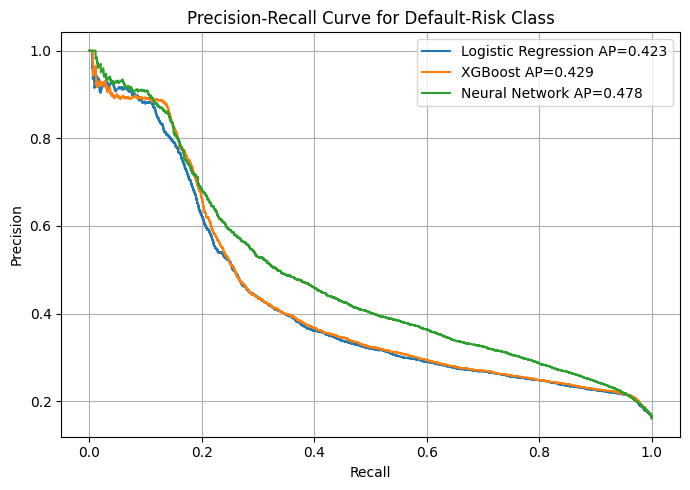

In [188]:
lr_model = joblib.load("lr_l2_weights_model.pkl")
xgb_model = joblib.load("best_XGB_sampler_model.pkl")

lr_model = patch_all_simple_imputers(lr_model)
xgb_model = patch_all_simple_imputers(xgb_model)

plt.figure(figsize=(7, 5))

# Treat class 0 as the positive/default-risk class(class 1)
y_test_class0 = (y_test == 0).astype(int)

# ============================================================
# Logistic Regression and XGBoost
# ============================================================

models = {
    "Logistic Regression": lr_model,
    "XGBoost": xgb_model
}

for name, model in models.items():

    proba = model.predict_proba(X_test_fe)

    # Get probability of class 0
    class_0_index = list(model.classes_).index(0)
    y_score = proba[:, class_0_index]

    precision, recall, thresholds = precision_recall_curve(
        y_test_class0,
        y_score
    )
    #Calculates the precision and recall of many different thresholds

    #Summarizes the precision and recall curve into 1 number
    ap = average_precision_score(y_test_class0, y_score)

    plt.plot(recall, precision, label=f"{name} AP={ap:.3f}")


# ============================================================
# Neural Network
# ============================================================

# You already created this in your NN block:
# test_pd_nn = nn_pipe.predict_proba(X_test_fe)[:, 0]

nn_y_score = test_pd_nn

precision, recall, thresholds = precision_recall_curve(
    y_test_class0,
    nn_y_score
)

ap = average_precision_score(y_test_class0, nn_y_score)

plt.plot(recall, precision, label=f"Neural Network AP={ap:.3f}")


# ============================================================
# Final plot
# ============================================================

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Default-Risk Class")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#Saved sklearn/imblearn model pipelines are patched immediately after loading to restore missing SimpleImputer internal attributes caused by sklearn version differences before prediction or evaluation.